<a href="https://colab.research.google.com/github/adwait-ops/GW-ODW-2025/blob/main/Challenge_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import files

uploaded = files.upload()

Saving challenge1.gwf to challenge1 (1).gwf


Sampling Rate: 4096.0 Hz
Duration: 128.0 seconds


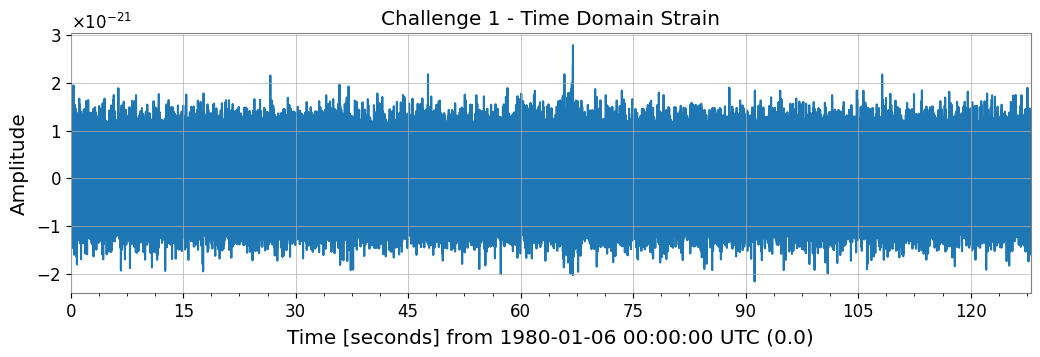

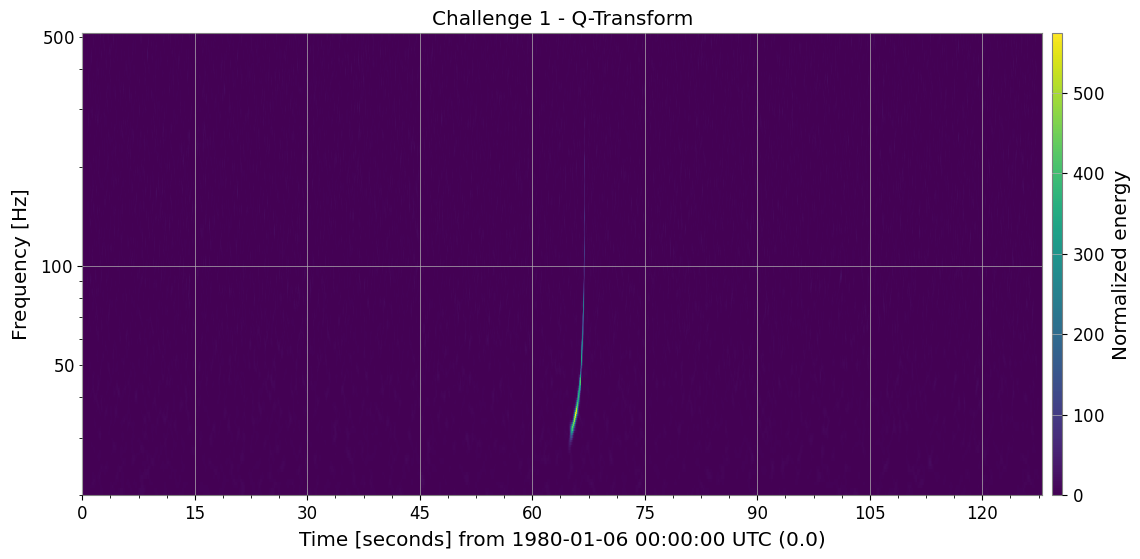

In [21]:
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

#load data
file_path = 'challenge1.gwf'
channel_name = "H1:CHALLENGE1"
strain = TimeSeries.read(file_path, channel=channel_name)

#sampling rate and duration
sample_rate = strain.sample_rate.value
duration = strain.duration.value

print(f"Sampling Rate: {sample_rate} Hz")
print(f"Duration: {duration} seconds")

#plot data
plot = strain.plot()
ax = plot.gca()
ax.set_title("Challenge 1 - Time Domain Strain")
ax.set_ylabel("Amplitude")
plt.show()

#q transform
qt = strain.q_transform(frange=(20, 512))
plot = qt.plot()
ax = plot.gca()
ax.set_title("Challenge 1 - Q-Transform")
ax.set_yscale('log')
ax.colorbar(label="Normalized energy")
plt.show()

--- Challenge 1 Results ---
The signal was found at: 64.9109 seconds
The Matched Filter SNR is: 0.00


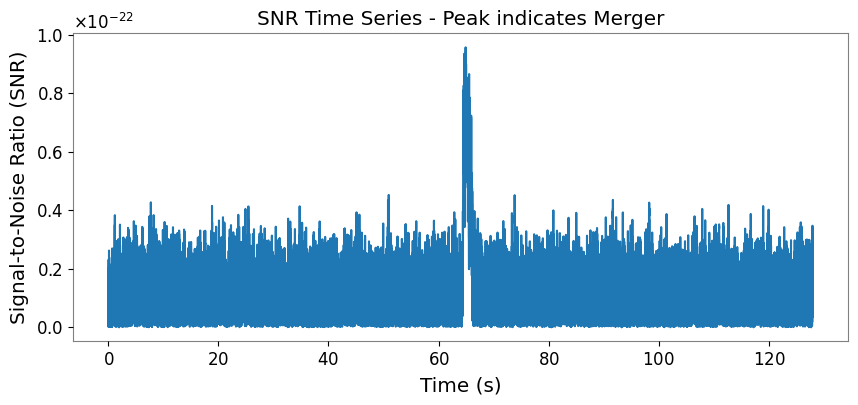

In [22]:
import numpy as np
from pycbc.filter import matched_filter
from pycbc.waveform import get_td_waveform
from gwpy.timeseries import TimeSeries

from pycbc import frame
strain = frame.read_frame('challenge1.gwf', 'H1:CHALLENGE1')


hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=30,
                         mass2=30,
                         delta_t=strain.delta_t,
                         f_lower=20)

hp.resize(len(strain))


snr = matched_filter(hp, strain, low_frequency_cutoff=20)

import numpy as np


snr_array = np.absolute(snr_segment.numpy())
peak_idx = snr_array.argmax()

peak_time = snr_segment.sample_times[peak_idx]
peak_snr = snr_array[peak_idx]

print(f"--- Challenge 1 Results ---")
print(f"The signal was found at: {peak_time:.4f} seconds")
print(f"The Matched Filter SNR is: {peak_snr:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(snr.sample_times, abs(snr))
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.xlabel('Time (s)')
plt.title('SNR Time Series - Peak indicates Merger')
plt.grid()
plt.show()